In [ ]:
!pip install pdf2image pillow
!pip install poppler-utils
!pip install -U "huggingface_hub"
!pip install -U json-repair
!pip install transformers
!pip install optimum
!pip install wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 11.0 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.1.8
    Uninstalling click-8.1.8:
      Successfully uninstalled click-8.1.8
  Attempting uninstall: typer
    Found existing installation: typer 0.23.1
    Uninstalling typer-0.23.1:
      Successfully uninstalled typer-0.23.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
litellm 1.83.4 requires click==8.1.8, but you have click 8.3.2 which is incompatible.
gradio 5.50.0 requires pydantic<=2.12.3,>=2.0, but you have pydantic 2.12.5 which is incompatible.


In [ ]:
!pip install -U litellm
!pip install datsets
!pip install torch==2.8.0
!pip install torchvision==0.23
!pip install torchaudio==2.8.0
!pip install docker

  Using cached click-8.1.8-py3-none-any.whl.metadata (2.3 kB)
INFO: pip is looking at multiple versions of typer to determine which version is compatible with other requirements. This could take a while.
  Using cached typer-0.24.0-py3-none-any.whl.metadata (16 kB)
  Using cached typer-0.23.2-py3-none-any.whl.metadata (16 kB)
  Using cached typer-0.23.1-py3-none-any.whl.metadata (16 kB)
Using cached click-8.1.8-py3-none-any.whl (98 kB)
Using cached typer-0.23.1-py3-none-any.whl (56 kB)
  Attempting uninstall: click
    Found existing installation: click 8.3.2
    Uninstalling click-8.3.2:
      Successfully uninstalled click-8.3.2
  Attempting uninstall: typer
    Found existing installation: typer 0.24.1
    Uninstalling typer-0.24.1:
      Successfully uninstalled typer-0.24.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer-slim 0.24.0 requires typer>=0

In [ ]:
!wandb login

wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: yousef-jo-reda14 (yousef-jo-reda14-egypt-japan-university-of-science-and-t) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
!rm -rf /content/LlamaFactory
%cd /content
!git clone https://github.com/hiyouga/LLaMA-Factory.git
%cd /content/LLaMA-Factory
!pip install -e .

/content
fatal: destination path 'LLaMA-Factory' already exists and is not an empty directory.
/content/LLaMA-Factory
Obtaining file:///content/LLaMA-Factory
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 8.6 MB/s eta 0:00:00
  Using cached typer-0.24.1-py3-none-any.whl.metadata (16 kB)
  Using cached click-8.3.2-py3-none-any.whl.metadata (2.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.8/375.8 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 462.4/462.4 kB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 92.4 MB/s e

In [ ]:
from huggingface_hub import login
from google.colab import userdata

hf_token = userdata.get('my-hf')
login(token=hf_token)

In [ ]:
from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


In [ ]:
import os
from os.path import join
import random
from tqdm.auto import tqdm
import json

from google.colab import userdata
import litellm
from litellm import completion

from glob import glob
from pdf2image import convert_from_path
from PIL import Image
from PIL import ImageEnhance
import numpy as np
import matplotlib.pyplot as plt

openrouter_token= userdata.get("openrouter")
os.environ["OPENROUTER_API_KEY"] = "https://openrouter.ai/api/vi"
os.environ["OPENROUTER_API_KEY"] = openrouter_token

data_dir="//gdrive/MyDrive/VLM Finetuining OCR/assets/downloaded_images"

def parse_json(text):
  try:
    return json_repair.loads(text)
  except:
    return None


In [ ]:
# @title
def preprocessing_images(image, max_width=600):
  """prepare images to ocr
  image : PIL image object
  steps:
  1- convert images to greyscale to reduce the size and improve ocr
  2- resizing and maintain aspect ratio
  3- increase contrast because the font is not fully clear
    """
  #Convert to greyscale
  grey_image = image.convert("L")

  #Resize it
  if grey_image.width > max_width:
    ratio = max_width/grey_image.width
    new_hight= int(grey_image.height *ratio)
    grey_image= grey_image.resize((max_width, new_hight), Image.LANCZOS)

  #contrast
  enhancer = ImageEnhance.Contrast(grey_image)
  enhanced_image = enhancer.enhance(1.5)

  return enhanced_image



In [ ]:
# @title
#to split all the pdf files
output_dir = f"{data_dir}/pdf_images"
pdf_files = glob(f"{data_dir}/downloaded_pdfs/*.pdf")
max_width = 600

for pdf_file in tqdm(pdf_files):

    _ = convert_pdf_to_images(
        pdf_file,
        output_dir,
        max_width
    )

In [ ]:
# @title
import base64

def image_to_base64_data_uri(image_path):

    """Convert image to base64 data URI for APIs"""
    with open(image_path, 'rb') as image_file:
        img_base64 = base64.b64encode(image_file.read()).decode('utf-8')

    # Determine image type from extension
    ext = image_path.lower().split('.')[-1]
    mime_type = f"image/{ext}" if ext != "jpg" else "image/jpeg"

    return f"data:{mime_type};base64,{img_base64}"



prompt = """
# Document Analysis & Extraction Prompt

## Task
Extract structured data from document images and return as valid JSON. Use exact enumeration values provided. Extract text in its ORIGINAL SCRIPT - never transliterate or translate names, titles, or any text unless the original is in that script.

## Output Format

```json
{
  "document_classification": {
    "type": "enum: official_letter | decree | regulation | statistical_report | table_of_contents | administrative_decision | legal_amendment | memo | certificate | form | invoice | contract | court_ruling | minutes | circular | announcement | report | other",
    "subtype": "string or null",
    "category": "enum: legal | administrative | financial | statistical | correspondence | technical | hr | other",
    "primary_language": "enum: arabic | english | french | mixed | other",
    "secondary_languages": ["array of language codes if multilingual"]
  },

  "source": {
    "issuing_authority": "string: full organization name in ORIGINAL SCRIPT",
    "department": "string or null: specific division/unit in ORIGINAL SCRIPT",
    "location": "string or null: city/region",
    "document_number": "string or null: official reference number EXACTLY as shown",
    "related_references": ["array: all other document numbers mentioned anywhere in document"],
    "dates": {
      "primary_date": {
        "date_text": "string: main document date EXACTLY as written",
        "calendar_type": "enum: hijri | gregorian | unknown",
        "date_type": "enum: issue_date | effective_date | received_date | other",
        "indicators": "string: calendar markers like 'هـ' or 'م'",
        "location_in_document": "enum: header | body | footer | stamp | other"
      },
      "additional_dates": [
        {
          "date_text": "string: EXACTLY as written",
          "calendar_type": "enum: hijri | gregorian | unknown",
          "date_type": "enum: reference_date | deadline | expiry_date | effective_date | other",
          "context": "string: brief context of where/why this date appears",
          "indicators": "string or null"
        }
      ]
    }
  },

  "physical_properties": {
    "page_number": "string: e.g., '7', '7/254', 'single', 'unknown'",
    "total_pages": "integer or null",
    "image_type": "enum: digital | scanned | photographed | mixed | unknown",
    "quality": "enum: high | medium | low | illegible",
    "color_mode": "enum: color | grayscale | black_white | mixed",
    "has_watermark": "boolean",
    "watermark_description": "string or null",
    "has_security_pattern": "boolean",
    "security_pattern_description": "string or null",
    "orientation": "enum: portrait | landscape"
  },

  "official_marks": {
    "seals": [
      {
        "organization": "string: in ORIGINAL SCRIPT",
        "position": "enum: header | footer | center | top_right | top_left | bottom_right | bottom_left | margin | overlapping_text | other",
        "description": "string: detailed visual description",
        "is_digital": "boolean",
        "shape": "enum: circular | oval | rectangular | square | irregular | other"
      }
    ],
    "stamps": [
      {
        "type": "enum: approval | received | confidential | urgent | date_stamp | routing | registry | copy | original | other",
        "text_content": "string: ALL text on stamp in ORIGINAL SCRIPT",
        "color": "enum: red | blue | black | green | purple | brown | other",
        "position": "enum: header | footer | center | top_right | top_left | bottom_right | bottom_left | margin | overlapping_text | other",
        "is_digital": "boolean",
        "shape": "enum: circular | rectangular | square | oval | irregular"
      }
    ],
    "barcodes_qr": [
      {
        "type": "enum: barcode | qr_code | data_matrix | other",
        "position": "string",
        "readable_data": "string or null"
      }
    ]
  },

  "signatures_authorization": {
    "signatories": [
      {
        "name": "string: EXACTLY as written in ORIGINAL SCRIPT (Arabic/English/etc)",
        "name_transliteration": "string or null: only if BOTH scripts appear in document",
        "title": "string: official position in ORIGINAL SCRIPT",
        "signature_type": "enum: handwritten | digital | stamp | printed_name | not_present",
        "position": "enum: bottom_left | bottom_right | bottom_center | top_right | top_left | middle_right | middle_left | end_of_document | other",
        "role": "enum: primary_signatory | co_signatory | witness | approver | preparer | reviewer | other"
      }
    ],
    "approval_chain": [
      {
        "step": "integer: order in chain (1, 2, 3...)",
        "role": "enum: prepared_by | reviewed_by | approved_by | authorized_by | noted_by | verified_by | other",
        "name": "string or null: in ORIGINAL SCRIPT",
        "title": "string or null: in ORIGINAL SCRIPT",
        "date": "string or null"
      }
    ]
  },

  "routing_distribution": {
    "addressed_to": [
      {
        "type": "enum: person | department | organization | position | general",
        "name": "string: in ORIGINAL SCRIPT",
        "honorific": "string or null: titles like 'فضيلة', 'سعادة', 'معالي'"
      }
    ],
    "carbon_copy": [
      {
        "type": "enum: person | department | organization | position",
        "name": "string: in ORIGINAL SCRIPT"
      }
    ],
    "forwarded_to": [
      {
        "type": "enum: person | department | organization | position",
        "name": "string: in ORIGINAL SCRIPT",
        "date": "string or null"
      }
    ],
    "file_reference": "string or null: internal filing/tracking code",
    "classification": "string or null: security/filing classification in ORIGINAL SCRIPT"
  },

  "content": {
    "subject": "string: document subject/title in ORIGINAL SCRIPT",
    "subject_translation": "string or null: only if explicitly needed",
    "keywords": ["array: 5-10 keywords in ORIGINAL SCRIPT"],
    "full_text": "string: complete text extraction with line breaks, in ORIGINAL SCRIPT",
    "has_tables": "boolean",
    "tables": [
      {
        "title": "string or null: in ORIGINAL SCRIPT",
        "headers": ["array: column headers in ORIGINAL SCRIPT"],
        "rows": [
          ["array of cell values per row in ORIGINAL SCRIPT"]
        ],
        "notes": "string or null"
      }
    ],
    "has_lists": "boolean",
    "lists": [
      {
        "type": "enum: numbered | bulleted | lettered | arabic_numbered | hierarchical",
        "items": ["array: items in ORIGINAL SCRIPT with hierarchy preserved"]
      }
    ],
    "has_charts": "boolean",
    "charts": [
      {
        "type": "enum: bar | line | pie | area | scatter | table | mixed | other",
        "title": "string or null: chart title in ORIGINAL SCRIPT",
        "description": "string: brief description of what chart displays",
        "data": [
          {
            "label": "string: category/bar/data point label in ORIGINAL SCRIPT",
            "value": "number or string: numerical value EXACTLY as shown",
            "position": "integer: order/sequence (1, 2, 3...)"
          }
        ],
        "axis_info": {
          "x_axis_label": "string or null: in ORIGINAL SCRIPT",
          "y_axis_label": "string or null: in ORIGINAL SCRIPT",
          "x_axis_type": "enum: categorical | numerical | date | other",
          "y_axis_type": "enum: categorical | numerical | percentage | other"
        },
        "notes": "string or null: any footnotes or additional chart info"
      }
    ],
    "legal_articles": [
      {
        "article_number": "string: in ORIGINAL SCRIPT e.g., 'المادة الأولى', 'Article 1'",
        "article_title": "string or null: in ORIGINAL SCRIPT",
        "content": "string: full article text in ORIGINAL SCRIPT"
      }
    ],
    "financial_data": [
      {
        "description": "string: in ORIGINAL SCRIPT",
        "amount": "string: numerical value EXACTLY as shown",
        "currency": "string: SAR, USD, etc. or in ORIGINAL SCRIPT"
      }
    ]
  },

  "structural_elements": {
    "header": {
      "present": "boolean",
      "content": "string or null: ALL header text in ORIGINAL SCRIPT",
      "has_logo": "boolean",
      "logo_description": "string or null",
      "reference_numbers": ["array: any reference numbers in header"]
    },
    "footer": {
      "present": "boolean",
      "content": "string or null: ALL footer text in ORIGINAL SCRIPT",
      "has_page_number": "boolean",
      "page_info": "string or null: page numbering format"
    },
    "letterhead": {
      "present": "boolean",
      "organization_name": "string or null: in ORIGINAL SCRIPT",
      "organization_name_secondary": "string or null: if in another language",
      "emblem_description": "string or null",
      "contact_info": "string or null: addresses, phones, emails, websites"
    },
    "margins_notes": {
      "has_margin_notes": "boolean",
      "margin_content": "string or null: any handwritten or printed margin notes in ORIGINAL SCRIPT"
    }
  },

  "attachments_references": {
    "attachments_mentioned": [
      {
        "description": "string: in ORIGINAL SCRIPT",
        "count": "integer or null",
        "reference_number": "string or null"
      }
    ],
    "referenced_documents": [
      {
        "type": "enum: law | regulation | decree | previous_decision | letter | circular | report | contract | minutes | other",
        "reference": "string: document identifier in ORIGINAL SCRIPT",
        "date": "string or null: if date is mentioned for this reference"
      }
    ]
  },

  "condition_notes": {
    "completeness": "enum: complete | partial | missing_pages | fragment | unknown",
    "legibility_issues": ["array: describe sections with poor legibility"],
    "physical_damage": "enum: none | minor | moderate | severe | not_applicable",
    "damage_description": "string or null",
    "handwritten_annotations": {
      "present": "boolean",
      "description": "string or null: describe notes, highlights, corrections"
    },
    "special_observations": "string or null"
  },

  "confidence_quality": {
    "overall_confidence": "enum: high | medium | low",
    "uncertain_elements": ["array: list specific elements with low confidence"],
    "requires_manual_review": "boolean",
    "review_reasons": ["array: specific areas needing verification"]
  }
}
```

## Critical Extraction Rules

### 1. ORIGINAL SCRIPT REQUIREMENT ⚠️
**MOST IMPORTANT**: Extract ALL text in its original script/language:
- Arabic names stay in Arabic: سلمان بن فوزان الفوزان (NOT "Salman bin Fawzan Al-Fawzan")
- Arabic titles stay in Arabic: القائم بعمل نائب وزير العدل (NOT translated)
- Do NOT romanize, transliterate, or translate unless the document itself shows both versions
- Preserve all diacritics and special characters exactly

### 2. Date Extraction Structure
**PRIMARY vs ADDITIONAL dates**:
- **primary_date**: The main document date (usually in header: "التاريخ")
- **additional_dates**: All other dates referenced in the body (from previous documents, deadlines, references)
- NEVER mix these - the primary date must be clearly identified
- Extract the date position: header dates are usually primary/issue dates

### 3. Name and Title Extraction
When extracting signatories or addressed persons:
```json
{
  "name": "سلمان بن فوزان الفوزان",  // ORIGINAL SCRIPT
  "title": "القائم بعمل نائب وزير العدل"  // ORIGINAL SCRIPT
}
```
NOT:
```json
{
  "name": "Salman bin Fawzan Al-Fawzan",  // WRONG - transliterated
  "title": "Acting Deputy Minister of Justice"  // WRONG - translated
}
```

### 4. Document Numbers
Extract EXACTLY as shown, preserving:
- All numbers and separators: "13/ت/8795" not "13-8795"
- Arabic and Latin characters: "م/38" not "M/38"
- Parentheses and formatting: "(م/38)" not "م/38"

### 5. Reference Numbers vs Content References
- **document_number**: The THIS document's official number (in header)
- **related_references**: OTHER document numbers mentioned in text body
- **file_reference**: Internal tracking/filing number (often in footer)

### 6. Stamps and Seals - Key Differences
**Seals** (الختم):
- Usually embossed or official emblems
- Circular/oval shapes with organization logo
- May be digital or physical
- Example: Ministry emblem at top

**Stamps** (الطابع):
- Ink impressions with text
- Rectangular/square more common
- Date stamps, approval stamps, "صورة" stamps
- Usually red, blue, or black ink

### 7. Honorifics in Routing
Capture separately:
```json
{
  "type": "position",
  "name": "نائب وزير العدل",
  "honorific": "فضيلة"
}
```
Common honorifics: فضيلة، سعادة، معالي، صاحب السمو

### 8. Header Components
Extract ALL elements from header:
- Organization name (right side usually)
- Department name
- Document number ("الرقم")
- Date ("التاريخ")
- Attachments line ("المرفقات")
- Subject line ("الموضوع")
- Reference number boxes (e.g., [277])

### 9. Chart and Graph Data Extraction
**CRITICAL**: Extract actual data values, not summaries:

For **Bar Charts**:
- Each bar = one data object with label + value
- Extract values from bars (read the number labels)
- Maintain order left-to-right or as shown
- Example for chart with 3 bars:
```json
"data": [
  {"label": "التعديلات", "value": 33, "position": 1},
  {"label": "المواد الملغية", "value": 51, "position": 2},
  {"label": "المواد والفقرات المضافة", "value": 25, "position": 3}
]
```

For **Line Charts**:
- Each point = one data object
- Extract x and y values
- Maintain sequence

For **Pie Charts**:
- Each slice = one data object with label + value/percentage

**DO NOT** create a text summary like "التعديلات: 33, المواد الملغية: 51" ❌
**DO** extract structured data array with each value as separate object ✓

Read numbers directly from:
- Value labels on/above bars
- Data point labels
- Axis tick marks
- Legend entries with values

### 10. Table Data Extraction
For tables, extract into structured format:
```json
"tables": [
  {
    "title": "عنوان الجدول",
    "headers": ["العمود الأول", "العمود الثاني", "العمود الثالث"],
    "rows": [
      ["قيمة 1-1", "قيمة 1-2", "قيمة 1-3"],
      ["قيمة 2-1", "قيمة 2-2", "قيمة 2-3"]
    ],
    "notes": "any table footnotes",
    "row_count": 2,
    "column_count": 3
  }
]
```

**Table Recognition**:
- Look for grid lines (horizontal/vertical)
- Header row usually bold or separated
- Aligned columns of data
- May have borders or just spacing

### 11. Full Text Requirements
In `full_text` field:
- Include ALL visible text
- Preserve line breaks with \n
- Keep original structure (indentation where meaningful)
- Include header, body, footer, and signatures
- Do NOT translate anything
- Include text from stamps if legible
- Include chart titles and labels (but data goes in charts section)

### 12. Referenced Documents
When document mentions other documents:
```json
{
  "type": "circular",
  "reference": "تعميم الوزارة رقم 13/ت/1839",
  "date": "12/8/1422هـ"
}
```
Extract: document type, full reference including number, and date if mentioned

## Chart and Table Extraction Examples

### Example 1: Bar Chart
For a bar chart showing three categories with values:
```json
{
  "type": "bar",
  "title": "(أ) التعديلات على النظام واللائحة",
  "description": "Bar chart showing amendments, repealed articles, and added articles",
  "data": [
    {"label": "التعديلات", "value": 33, "position": 1},
    {"label": "المواد الملغية", "value": 51, "position": 2},
    {"label": "المواد والفقرات المضافة", "value": 25, "position": 3}
  ],
  "axis_info": {
    "x_axis_label": null,
    "y_axis_label": null,
    "x_axis_type": "categorical",
    "y_axis_type": "numerical"
  },
  "notes": null
}
```

### Example 2: Multi-Category Bar Chart
For a chart with 7 different categories:
```json
{
  "type": "bar",
  "title": "(ب) المرفقات والملحقات",
  "description": "Bar chart showing counts of various legal documents and references",
  "data": [
    {"label": "لوائح متعلقة بالنظام", "value": 3, "position": 1},
    {"label": "الأحكام القضائية", "value": 98, "position": 2},
    {"label": "قرارات وتعاميم وزارة العدل", "value": 16, "position": 3},
    {"label": "تعاميم المجلس الأعلى للقضاء", "value": 32, "position": 4},
    {"label": "قرارات مجلس الوزراء ومجلس الشورى", "value": 4, "position": 5},
    {"label": "المراسيم الملكية", "value": 23, "position": 6},
    {"label": "الأوامر الملكية", "value": 4, "position": 7}
  ],
  "axis_info": {
    "x_axis_label": null,
    "y_axis_label": null,
    "x_axis_type": "categorical",
    "y_axis_type": "numerical"
  },
  "notes": null
}
```

### Example 3: Table Data
```json
{
  "title": "جدول المقارنة",
  "headers": ["البند", "العدد", "النسبة"],
  "rows": [
    ["التعديلات", "33", "30%"],
    ["المواد الملغية", "51", "46%"],
    ["المضافة", "25", "24%"]
  ],
  "notes": null,
  "row_count": 3,
  "column_count": 3
}
```

## Common Mistakes to Avoid

❌ **WRONG - Text summary instead of structured data**:
```json
"data_summary": "التعديلات: 33, المواد الملغية: 51, المواد والفقرات المضافة: 25"
```

✅ **CORRECT - Structured data array**:
```json
"data": [
  {"label": "التعديلات", "value": 33, "position": 1},
  {"label": "المواد الملغية", "value": 51, "position": 2},
  {"label": "المواد والفقرات المضافة", "value": 25, "position": 3}
]
```

❌ **WRONG - Missing values**:
```json
"axis_labels": ["التعديلات", "المواد الملغية", "المواد والفقرات المضافة"]
```

✅ **CORRECT - Labels with values**:
```json
"data": [
  {"label": "التعديلات", "value": 33, "position": 1},
  ...
]
```

❌ **WRONG - Translating labels**:
```json
{"label": "Amendments", "value": 33}
```

✅ **CORRECT - Original script**:
```json
{"label": "التعديلات", "value": 33}
```

### Saudi Official Letter/Circular Header:
```
[Logo]  المملكة العربية السعودية
        وزارة [الوزارة]
[###]   [إدارة]

الرقم: [number]         التاريخ: [date]
المرفقات: ______       الموضوع: [subject]
```

### Signature Block:
```
[Title line in Arabic]
[Handwritten signature]
[Printed name in Arabic]
```

### Footer Elements:
- Classification: "التصنيف:"
- Copy notation: "صورة لـ"
- File reference: "القيد رقم"
- Print date: "طبع في"
- Form number: "نموذج"

## Date Indicators Reference
- **هـ** or **ه** = Hijri calendar
- **م** = Gregorian (Miladi) calendar
- Format variations: ١٤٤٣/٩/١٣ or 1443/9/13 or ١٣-٩-١٤٤٣هـ
- Context: "التاريخ" means "Date", "بتاريخ" means "dated"

## Validation Checklist
Before returning JSON:
- [ ] All Arabic text kept in Arabic (not romanized)
- [ ] Primary document date separated from reference dates
- [ ] Document number vs file reference separated
- [ ] Names and titles in original script
- [ ] All enum values match specified options exactly
- [ ] No null in array fields (use empty array [])
- [ ] Valid JSON syntax (test with JSON parser)
- [ ] full_text includes all visible text
- [ ] Stamps vs seals correctly categorized

## Output Instructions
Return ONLY the JSON object. No markdown code blocks, no explanatory text. Start directly with `{` and end with `}`.
""".strip()

Evaluate base model

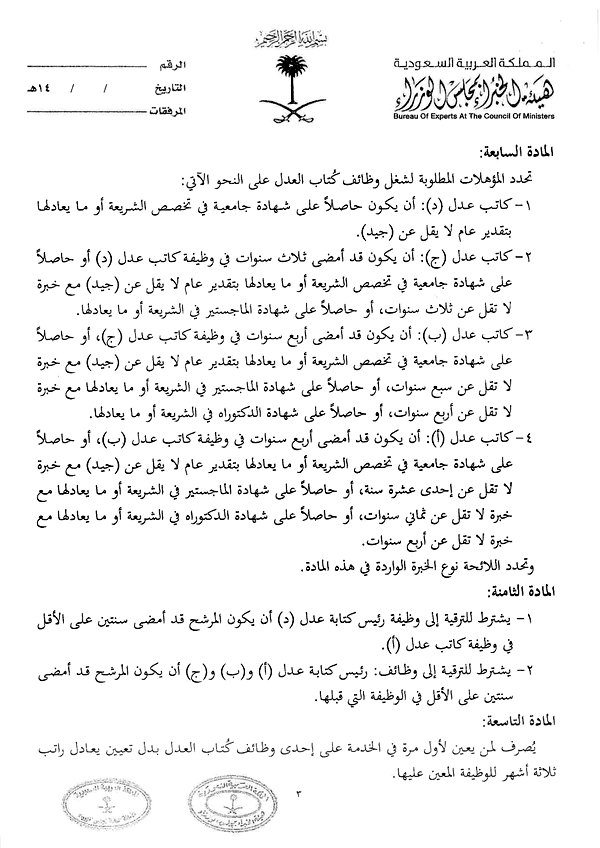

In [ ]:
from transformers import AutoProcessor, Gemma3ForConditionalGeneration
from PIL import Image
from IPython.display import Image as IPImage, display
import torch

model_id = "google/gemma-3-4b-it"

sample_image_path = f"{data_dir}/pdf_images/0001/page_006.jpg"
display(IPImage(filename=sample_image_path))


In [ ]:
model = Gemma3ForConditionalGeneration.from_pretrained(model_id,
    dtype="auto", device_map="auto"
).eval()

processor = AutoProcessor.from_pretrained(model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

...

The image processor of type `Gemma3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

In [ ]:
# prompt="""
# Act as an OCR Model.Extract the exact details of the image into a markdown format.

# ##output:
# ```markdown
# """.strip()
messages = [
    {
        "role": "system",
        "content": [{"type": "text", "text": "You are a helpful assistant."}]
    },
    {
        "role": "user",
        "content": [
            {"type": "image", "image": sample_image_path},
            {"type": "text", "text": prompt}
        ]
    }
]
inputs = processor.apply_chat_template(
    messages,
    add_generation_prompt=True, tokenize=True,
    return_dict=True, return_tensors="pt"
).to(model.device)

input_len = inputs["input_ids"].shape[-1]
with torch.inference_mode():
    generation = model.generate(**inputs, max_new_tokens=1024, do_sample=False)
    generation = generation[0][input_len:]

decoded = processor.decode(generation, skip_special_tokens=True)
print(decoded)

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


evaluate gemini3 model

In [ ]:
cloud_model_id = "openrouter/google/gemini-3-flash-preview"
sample_image_path = f"{data_dir}/pdf_images/0001/page_006.jpg"

In [ ]:
messages=[
    {
        "role": "user",
        "content": [
            {"type": "text", "text": prompt},
            {
                "type": "image_url",
                "image_url": {
                    "url": image_to_base64_data_uri(sample_image_path)
                }
            }

        ]
    }
]

response = completion(messages= messages,
                      model=cloud_model_id,
                      max_tokens=4096)
print(response.choices[0].message.content)

Knowledge Distillation (transfer knowledg to the smaller model)

In [ ]:
output_dir = f"{data_dir}/pdf_images"
pdf_files = glob(f"{data_dir}/downloaded_pdfs/*.pdf")

pdf_images_paths = {}

for pdf_file in pdf_files:
    pdf_name = os.path.basename(pdf_file)
    pdf_images = glob(join(output_dir, pdf_name, "*.jpg"))

    pdf_images_paths[pdf_name] = pdf_images

In [ ]:
cloud_model_id = "openrouter/google/gemini-3-flash-preview"
output_sft_file = join(data_dir, "ocr-image-sft.jsonl")

price_per_1m_input_tokens = 0.5
price_per_1m_output_tokens = 3.0

prompt_tokens = 0
completion_tokens = 0

ix = 0

for pdf_name, images in pdf_images_paths.items():

    for img in tqdm(images, desc=f"file_{pdf_name}"):

        ix += 1

        # if ix < 500:
        #     continue

        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": image_to_base64_data_uri(img)
                        }
                    }

                ]
            }
        ]

        response = completion(
            model=cloud_model_id,
            messages=messages,
            max_tokens=8000
        )
        if response.choices[0].finish_reason != 'stop':
            print(f"Error Stop: {ix}", response.choices[0].finish_reason)
            continue
        llm_response = response.choices[0].message.content

        with open(output_sft_file, "a", encoding="utf8") as dest:

            dest.write(json.dumps(
                {
                    "id": ix,
                    "pdf_name": pdf_name,
                    "image_path": img,
                    "model_id": cloud_model_id,
                    "output": llm_response,
                },
                default=str, ensure_ascii=False,
            ) + "\n")

        prompt_tokens += response.usage.prompt_tokens
        completion_tokens += response.usage.completion_tokens

        if (ix % 3) == 0:
            cost_input = (prompt_tokens / 1_000_000) * price_per_1m_input_tokens
            cost_output = (completion_tokens / 1_000_000) * price_per_1m_output_tokens
            total_cost = cost_input + cost_output

            print(f"Iteration {ix}: Total Cost = ${total_cost:.4f} ")


In [ ]:
output_dir = f"{data_dir}/pdf_images"
output_sft_file=join(data_dir,"ocr-image-sft.jsonl")

In [ ]:
for line in open(output_sft_file):
  record = json.loads(line.strip())

  break

In [ ]:
llm_finetunning_data=[]

task_1_message = """
You are a professional OCR Details Extractor.
Your rule to extract: the page markdown content in addition to the structural_elements of the document.
Extract the final output into a json format.
Do not generate any introduction or conclusion.
""".strip()

task_2_message = """
You are a professional OCR Details Extractor.
Your rule to extract the: document_classification, source, physical_properties, official_marks, signatures_authorization, routing_distribution, attachments_references, condition_notes and confidence_quality of the document.
Extract the final output into a json format.
Do not generate any introduction or conclusion.
""".strip()

val_pdf_files = ['0011.pdf', '0006.pdf', '0001.pdf']

train_ds = []
val_ds = []

image_paths_set= set()

for line in open(output_sft_file):
  if line.strip() == "":
    continue
  record = json.loads(line.strip())
  pdf_name = record['pdf_name']


  llm_output = parse_json(record['output'])
  if not llm_output:
      continue

  if record["image_path"] in image_paths_set:
    continue
  image_paths_set.add(record["image_path"])


task_1_output = {
        'content': llm_output['content'],
        'structural_elements': llm_output.get("structural_elements", ""),
    }

    del llm_output['content']

    if 'structural_elements' in llm_output:
        del llm_output['structural_elements']

    task_2_output = llm_output

    task_1_sft_recored = {
        "conversations": [
                {
                    "value": "<image>"+task_1_message,
                    "from": "human"
                },
                {
                    "value": json.dumps(
                        task_1_output,
                        ensure_ascii=False, default=str
                    ),
                    "from": "gpt"
                }
            ],
        "images": [
            record['image_path']
        ]
    }

    task_2_sft_recored = {
        "conversations": [
                {
                    "value": "<image>"+task_2_message,
                    "from": "human"
                },
                {
                    "value": json.dumps(
                        task_2_output,
                        ensure_ascii=False, default=str
                    ),
                    "from": "gpt"
                }
            ],
        "images": [
            record['image_path']
        ]
    }

    if pdf_name in val_pdf_files:
        val_ds.append(task_1_sft_recored)
        val_ds.append(task_2_sft_recored)
    else:
        train_ds.append(task_1_sft_recored)
        train_ds.append(task_2_sft_recored)


random.Random(101).shuffle(val_ds)
random.Random(101).shuffle(train_ds)


In [ ]:
os.makedirs(
    join(data_dir, "datasets", "llamafactory-ocr-finetune-data"), exist_ok=True
)

with open(join(data_dir, "datasets", "llamafactory-ocr-finetune-data", "train-v1.json") , "w") as dest:
    json.dump(train_ds, dest, ensure_ascii=False, default=str)

with open(join(data_dir, "datasets", "llamafactory-ocr-finetune-data", "val-v1.json") , "w") as dest:
    json.dump(val_ds, dest, ensure_ascii=False, default=str)

In [ ]:
import yaml

path = "/content/LlamaFactory/examples/train_lora/OCR_file_tuining.yaml"

with open(path, "r") as f:
    data = yaml.safe_load(f)

print(data["model_name_or_path"])

google/gemma-3-4b-it


In [ ]:
import os

print(os.path.isdir("/content/LlamaFactory/data"))  # MUST be True
print(os.path.exists("/content/LlamaFactory/data/dataset_info.json"))  # MUST be True

True
True


In [ ]:
!python -m llamafactory.cli train --help

[WARNING|2026-04-12 11:49:59] llamafactory.extras.misc:155 >> Version checking has been disabled, may lead to unexpected behaviors.
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")
usage: cli.py [-h] [--model_name_or_path MODEL_NAME_OR_PATH]
              [--adapter_name_or_path ADAPTER_NAME_OR_PATH]
              [--adapter_folder ADAPTER_FOLDER] [--cache_dir CACHE_DIR]
              [--use_fast_tokenizer [USE_FAST_TOKENIZER]]
              [--no_use_fast_tokenizer] [--resize_vocab [RESIZE_VOCAB]]
              [--split_special_tokens [

In [ ]:
import os
os.environ["DISABLE_VERSION_CHECK"] = "1"

!python -m llamafactory.cli train \
  /content/LlamaFactory/examples/train_lora/OCR_file_tuining.yaml \
  --dataset_dir /content/LlamaFactory/data \
  --model_name_or_path google/gemma-3-4b-it

[WARNING|2026-04-12 11:52:02] llamafactory.extras.misc:155 >> Version checking has been disabled, may lead to unexpected behaviors.
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/content/LLaMA-Factory/src/llamafactory/cli.py", line 31, in <module>
    main()
  File "/content/LLaMA-Factory/src/llamafactory/cli.py", line 24, in main
    launcher.launch()
  File "/content/LLaMA-Factory/src/llamafactory/launcher.py", line 157, in launch
    run_exp()
  File "/content/LLaMA-Factory/src/llamafactory/train/tuner.py", line 130, in run_exp
    args = read_args(args)
           ^^^^^^^^^^^^^^^
  File "/content/LLaMA-Factory/src/llamafactory/hparams/parser.py", line 76, in read_args
    dict_config = OmegaConf.load(Path(sys.argv[1]).absolute())
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/omegaconf/omegaconf.py", line 189, in load


In [ ]:
!pip install colab-xterm
%load_ext colabxterm
%xterm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.6/115.6 kB 5.4 MB/s eta 0:00:00


Launching Xterm...

<IPython.core.display.Javascript object>